# Monsoon Onset 2025 — IMD 1° Rainfall
Detect and visualise the gridded monsoon onset date for **2025** using the IMD 1-degree daily rainfall dataset.

## 1. Import Required Libraries

In [50]:
import sys
import os
import importlib
sys.path.insert(0, os.path.abspath(".."))   # so monsoon_onset package is found

import yaml
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import BoundaryNorm

# Force-reload the package so any source changes take effect in the kernel
import monsoon_onset.plotter
import monsoon_onset.loader
import monsoon_onset.detector
importlib.reload(monsoon_onset.plotter)
importlib.reload(monsoon_onset.loader)
importlib.reload(monsoon_onset.detector)

from monsoon_onset.loader import load_rainfall
from monsoon_onset.detector import detect_onset
from monsoon_onset.plotter import plot_climatological_onset, doy_to_date_string

%matplotlib inline
print("All imports OK")

All imports OK


## 2. Load Configuration File
Load the IMD 1-degree YAML config which specifies the data paths, variable names, and onset parameters.

In [44]:
config_path = "../configs/imd_1deg.yaml"

with open(config_path) as f:
    cfg = yaml.safe_load(f)

dataset_cfg = cfg["dataset"]
onset_cfg   = cfg["onset"]

print(f"Dataset : {dataset_cfg['name']}")
print(f"Data folder: {dataset_cfg['data_folder']}")
print(f"Threshold file: {dataset_cfg['threshold_file']}")
print(f"Onset window: {onset_cfg['wet_spell_window']} days, dry-spell window: {onset_cfg['dry_spell_window']} days")

Dataset : IMD_1deg
Data folder: /Users/Rajat/Library/CloudStorage/OneDrive-TheUniversityofChicago/documents/conferences/icts_monsoon_26/mr_onset/data/imd
Threshold file: /Users/Rajat/Library/CloudStorage/OneDrive-TheUniversityofChicago/documents/conferences/icts_monsoon_26/mr_onset/data/mwset1x1.nc4
Onset window: 5 days, dry-spell window: 10 days


## 3. Load Threshold Data
Open the wet-spell threshold file (`mwset1x1.nc4`) and extract the `MWmean` DataArray — the minimum 5-day rainfall required to declare onset at each grid point.

In [45]:
threshold_var = dataset_cfg.get("threshold_var", "MWmean")

thresh_ds = xr.open_dataset(dataset_cfg["threshold_file"])
thresh_da = thresh_ds[threshold_var]

print(f"Threshold variable : {threshold_var}")
print(f"Threshold shape    : {thresh_da.shape}")
print(f"Threshold dims     : {thresh_da.dims}")
thresh_da

Threshold variable : MWmean
Threshold shape    : (33, 35)
Threshold dims     : ('lat', 'lon')


<xarray.DataArray 'MWmean' (lat: 33, lon: 35)> Size: 9kB
[1155 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 264B 6.5 7.5 8.5 9.5 10.5 ... 35.5 36.5 37.5 38.5
  * lon      (lon) float64 280B 66.5 67.5 68.5 69.5 ... 97.5 98.5 99.5 100.5
Attributes:
    long_name:               Mean wet threshold
    units:                   mm
    description:             Mean wet threshold for first wet spell detection
    source_variable:         RAINFALL
    spatial_resolution_lat:  1.0 degrees
    spatial_resolution_lon:  1.0 degrees
    algorithm_parameters:    lseason=214, defdry=1, sw=5, wet=0, sd=10, dry=5...

## 3. Visualising Local Wet-spell Threshold


Loaded India outline from: /Users/Rajat/Library/CloudStorage/OneDrive-TheUniversityofChicago/documents/conferences/icts_monsoon_26/mr_onset/data/ind_map_shpfile/india_shapefile.shp


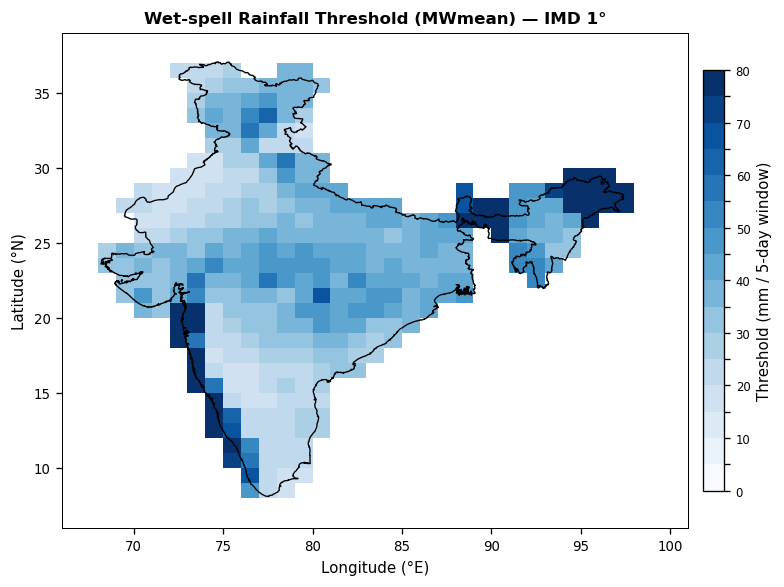

In [51]:
from monsoon_onset.plotter import get_india_outline

fig, ax = plt.subplots(figsize=(7, 5), dpi=120)

thresh_plot = thresh_da.squeeze()

# Discrete colorbar: 0–80 mm, 5 mm intervals
boundaries = np.arange(0, 85, 5)
cmap_obj   = plt.colormaps.get_cmap("Blues").resampled(len(boundaries) - 1)
norm       = BoundaryNorm(boundaries, cmap_obj.N, clip=True)

im = ax.pcolormesh(
    thresh_plot.lon, thresh_plot.lat, thresh_plot.values,
    cmap=cmap_obj, norm=norm, shading="auto",
    linewidth=0, edgecolors="none"
)

# India outline — shapefile path read directly from dataset config
shp_path = dataset_cfg.get("shapefile")
for lons_b, lats_b in get_india_outline(shapefile_path=shp_path):
    ax.plot(lons_b, lats_b, color="black", linewidth=0.8)

ax.patch.set_visible(False)

cbar = fig.colorbar(im, ax=ax, orientation="vertical", pad=0.02, shrink=0.85,
                    ticks=boundaries, spacing="uniform")
cbar.set_label("Threshold (mm / 5-day window)", fontsize=9)
cbar.ax.tick_params(labelsize=7)
cbar.set_ticklabels([str(int(b)) if b % 10 == 0 else "" for b in boundaries])

ax.set_title("Wet-spell Rainfall Threshold (MWmean) — IMD 1°", fontsize=10, fontweight="bold")
ax.set_xlabel("Longitude (°E)", fontsize=9)
ax.set_ylabel("Latitude (°N)", fontsize=9)
ax.tick_params(labelsize=8)

for side in ["top", "right", "bottom", "left"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(0.6)

plt.tight_layout()
plt.show()

## 4. Load IMD Rainfall Data for 2025
Use the `load_rainfall` function from `monsoon_onset.loader`. It reads the yearly NetCDF file, applies the dimension rename mapping, and returns a standardised DataArray.

In [47]:
YEAR = 2025

rainfall_da = load_rainfall(YEAR, dataset_cfg)

print(f"\nRainfall shape : {rainfall_da.shape}")
print(f"Rainfall dims  : {rainfall_da.dims}")
print(f"Time range     : {str(rainfall_da.time.values[0])[:10]}  →  {str(rainfall_da.time.values[-1])[:10]}")
print(f"Lat range      : {float(rainfall_da.lat.min()):.1f} – {float(rainfall_da.lat.max()):.1f}")
print(f"Lon range      : {float(rainfall_da.lon.min()):.1f} – {float(rainfall_da.lon.max()):.1f}")
rainfall_da

Loading 2025 rainfall from: /Users/Rajat/Library/CloudStorage/OneDrive-TheUniversityofChicago/documents/conferences/icts_monsoon_26/mr_onset/data/imd/data_2025.nc
Renamed dimensions: {'LONGITUDE': 'lon', 'LATITUDE': 'lat', 'TIME': 'time'}

Rainfall shape : (365, 33, 35)
Rainfall dims  : ('time', 'lat', 'lon')
Time range     : 2025-01-01  →  2025-12-31
Lat range      : 6.5 – 38.5
Lon range      : 66.5 – 100.5


<xarray.DataArray 'RAINFALL' (time: 365, lat: 33, lon: 35)> Size: 2MB
[421575 values with dtype=float32]
Coordinates:
  * lon      (lon) float64 280B 66.5 67.5 68.5 69.5 ... 97.5 98.5 99.5 100.5
  * lat      (lat) float64 264B 6.5 7.5 8.5 9.5 10.5 ... 35.5 36.5 37.5 38.5
  * time     (time) datetime64[ns] 3kB 2025-01-01 2025-01-02 ... 2025-12-31
Attributes:
    long_name:  Rainfall
    units:      mm
    history:    From ind2025_1384i.grd

## 5. Compute Onset Dates for 2025
Run the wet-spell / dry-spell veto algorithm grid-point by grid-point using `detect_onset`. Returns a `[lat, lon]` DataArray of `datetime64` onset dates (`NaT` where no valid onset is found).

In [48]:
onset_da = detect_onset(
    rainfall_da=rainfall_da,
    threshold_da=thresh_da,
    year=YEAR,
    cfg=onset_cfg,
)

# Convert onset datetime → day-of-year for plotting
onset_doy = xr.where(
    onset_da.notnull(),
    onset_da.dt.dayofyear.astype(float),
    np.nan,
)
onset_doy.attrs["long_name"] = f"Monsoon Onset DOY {YEAR}"

# Quick summary
valid_pts = int(onset_doy.notnull().sum())
total_pts = int(onset_doy.size)
print(f"Valid onset grid points : {valid_pts} / {total_pts}")
print(f"Earliest onset : {doy_to_date_string(float(onset_doy.min()))}")
print(f"Latest onset   : {doy_to_date_string(float(onset_doy.max()))}")
onset_doy

Onset detection start: 2025-04-01
  Valid onsets: 326/1155 (28.2%)
Valid onset grid points : 326 / 1155
Earliest onset : 03/31
Latest onset   : 11/06


<xarray.DataArray (lat: 33, lon: 35)> Size: 9kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(33, 35))
Coordinates:
  * lat      (lat) float64 264B 6.5 7.5 8.5 9.5 10.5 ... 35.5 36.5 37.5 38.5
  * lon      (lon) float64 280B 66.5 67.5 68.5 69.5 ... 97.5 98.5 99.5 100.5
Attributes:
    long_name:  Monsoon Onset DOY 2025

## 6. Plot Onset Date Map for 2025
Use the package's `plot_climatological_onset` function (which accepts any single-year DOY map) to render a discrete-colourmap onset map.

Loaded India outline from: /Users/Rajat/Library/CloudStorage/OneDrive-TheUniversityofChicago/documents/conferences/icts_monsoon_26/mr_onset/data/ind_map_shpfile/india_shapefile.shp
Saved: ../output/onset_imd_2025_monthly.png


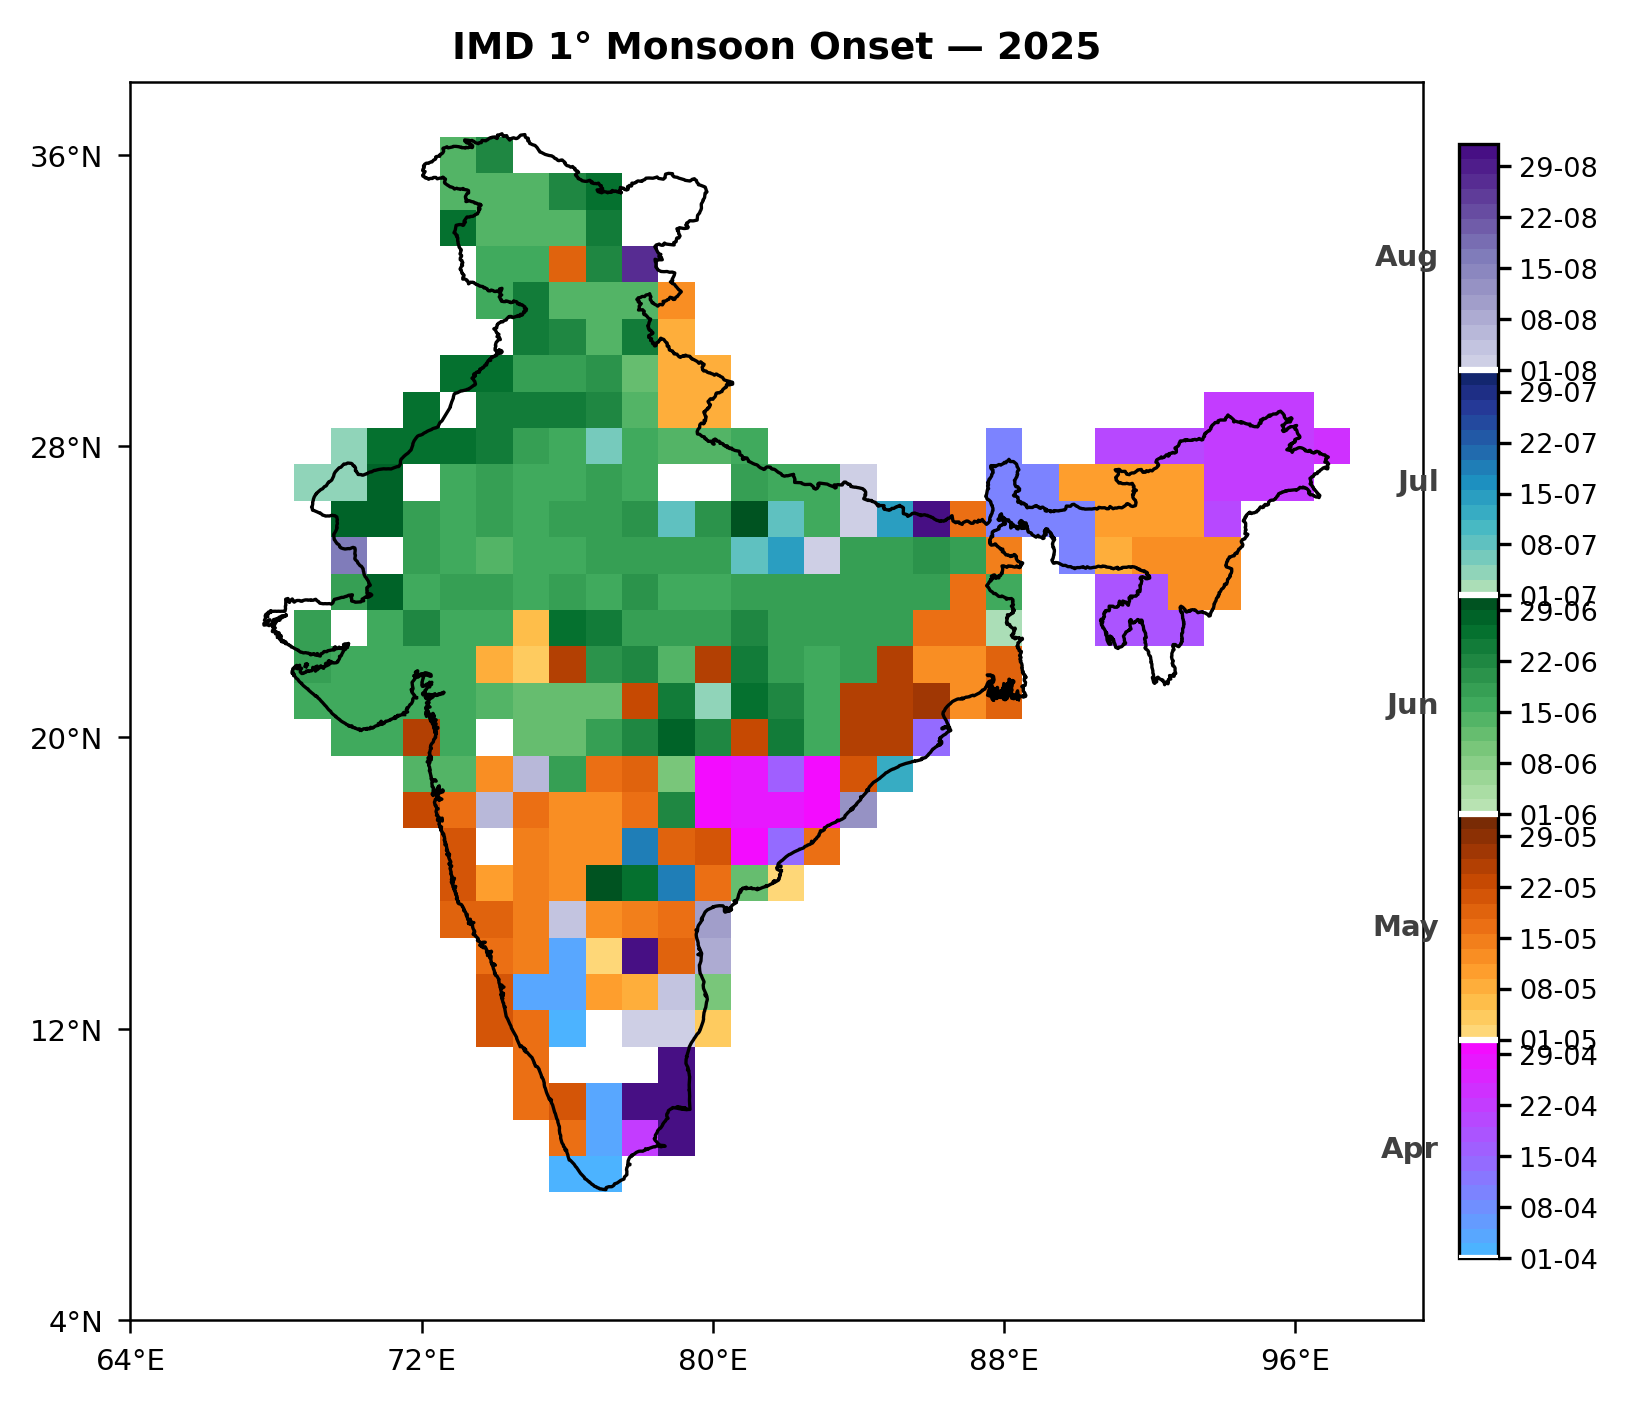

In [60]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.gridspec import GridSpec
from monsoon_onset.plotter import get_india_outline, doy_to_date_string
import os; os.makedirs("../output", exist_ok=True)

# ── Style constants ───────────────────────────────────────────────────────────
SMALL_SIZE     = 7
MEDIUM_SIZE    = 9
label_fontsize = 7
tick_length    = 3
tick_width     = 0.6
panel_lw       = 0.6
map_lw         = 0.8

# ── 1. DOY array from onset_da ────────────────────────────────────────────────
lon = onset_da.lon.values
lat = onset_da.lat.values

doy_vals = np.where(
    ~np.isnat(onset_da.values.astype("datetime64[ns]")),
    onset_da.dt.dayofyear.values.astype(float),
    np.nan,
)
# ensure [lat, lon]
if doy_vals.shape[0] == len(lon) and doy_vals.shape[1] == len(lat):
    doy_vals = doy_vals.T

# ── 2. Monthly stratified colormap ───────────────────────────────────────────
month_cmaps = {"Apr": plt.cm.cool,
               "May": plt.cm.YlOrBr,
               "Jun": plt.cm.Greens,
               "Jul": plt.cm.YlGnBu,
               "Aug": plt.cm.Purples}
month_doys  = {"Apr": (91, 121), "May": (121, 152), "Jun": (152, 182),
               "Jul": (182, 213), "Aug": (213, 244)}
N = 15

colors, bounds = [], []
for month, cmap in month_cmaps.items():
    d0, d1 = month_doys[month]
    colors.extend(cmap(np.linspace(0.3, 0.95, N)))
    bounds.extend(np.linspace(d0, d1, N, endpoint=False))
bounds.append(244)   # Aug 31

cmap_m = ListedColormap(colors)
norm_m = BoundaryNorm(bounds, cmap_m.N)

# ── 3. pcolormesh edges ───────────────────────────────────────────────────────
dlon = lon[1] - lon[0]
dlat = lat[1] - lat[0]
lon_edges = np.concatenate([lon - dlon/2, [lon[-1] + dlon/2]])
lat_edges = np.concatenate([lat - dlat/2, [lat[-1] + dlat/2]])
LON_e, LAT_e = np.meshgrid(lon_edges, lat_edges)
masked_data = np.ma.masked_invalid(doy_vals)

# ── 4. Figure + GridSpec ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(6, 6), dpi=300)
gs  = GridSpec(1, 14, figure=fig,
               hspace=0.1, wspace=0.3,
               left=0.08, right=0.92, top=0.85, bottom=0.15)
ax  = fig.add_subplot(gs[0, 0:12])

im = ax.pcolormesh(LON_e, LAT_e, masked_data,
                   cmap=cmap_m, norm=norm_m, shading="flat",
                   linewidth=0, edgecolors="none")

# India outline — shapefile path read directly from dataset config
shp_path = dataset_cfg.get("shapefile")
for lons_b, lats_b in get_india_outline(shapefile_path=shp_path):
    ax.plot(lons_b, lats_b, color="black", linewidth=map_lw)

# Hide background patch (removes inner box), keep spines
ax.patch.set_visible(False)

# ── Axis limits and ticks ─────────────────────────────────────────────────────
ax.set_xlim([lon[0] - 2, 100])
ax.set_ylim([lat[0] - 2, lat[-1]])

yticks = np.arange(lat[0] - 2, lat[-1] + 3, 8)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{int(y)}°N" for y in yticks], fontsize=label_fontsize)

xticks = np.arange(lon[0] - 2, lon[-1] + 3, 8)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{int(x)}°E" for x in xticks], fontsize=label_fontsize)

ax.set_title(f"IMD 1° Monsoon Onset — {YEAR}", fontsize=MEDIUM_SIZE, fontweight="bold")
ax.grid(False)
ax.tick_params("both", length=tick_length, width=tick_width, which="major")
ax.tick_params(axis="x", which="minor", bottom=False, top=False)
ax.tick_params(axis="y", which="minor", left=False, right=False)

for side in ["top", "right", "bottom", "left"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(panel_lw)

ax.set_aspect("equal", adjustable="box")

# ── 5. Colorbar ───────────────────────────────────────────────────────────────
pos = ax.get_position()
colorbar_height = pos.height * 0.9
vertical_offset = (pos.height - colorbar_height) / 2

cax = fig.add_axes([
    pos.x1 + 0.02,
    pos.y0 + vertical_offset,
    0.022,
    colorbar_height,
])

cbar = fig.colorbar(im, cax=cax, orientation="vertical", spacing="proportional")
cbar.ax.minorticks_off()

# Build tick positions (dd-mm) every 7 days within each month
ref = pd.Timestamp(f"{YEAR}-01-01")
tick_doys, tick_labels = [], []
for d0, d1 in month_doys.values():
    doy = d0
    while doy < d1:
        date = ref + pd.Timedelta(days=int(doy) - 1)
        tick_doys.append(doy)
        tick_labels.append(date.strftime("%d-%m"))
        doy += 7

cbar.set_ticks(tick_doys)
cbar.set_ticklabels(tick_labels, fontsize=SMALL_SIZE - 0.5)
cbar.ax.tick_params(labelsize=SMALL_SIZE - 0.5, length=3, width=0.8, pad=2)

# White separator lines between months + month name to the LEFT of colorbar
for month, (d0, d1) in month_doys.items():
    # separator at each month boundary
    cbar.ax.axhline(d0, color="white", linewidth=1.5, zorder=5)
    mid = (d0 + d1) / 2
    # month label placed to the left of the colorbar axes
    cbar.ax.text(-0.5, mid, month,
                 transform=cbar.ax.get_yaxis_transform(),
                 fontsize=SMALL_SIZE, va="center", ha="right",
                 color="0.25", fontweight="bold")

save_path = f"../output/onset_imd_{YEAR}_monthly.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()

## 7. Central Monsoon Zone (CMZ) — Polygon Overlay & Spatial Masking

Define the CMZ polygon, overlay it on the onset map, and extract only grid points that fall inside the polygon for further analysis.

Loaded India outline from: /Users/Rajat/Library/CloudStorage/OneDrive-TheUniversityofChicago/documents/conferences/icts_monsoon_26/mr_onset/data/ind_map_shpfile/india_shapefile.shp
Saved: ../output/onset_imd_2025_cmz.png


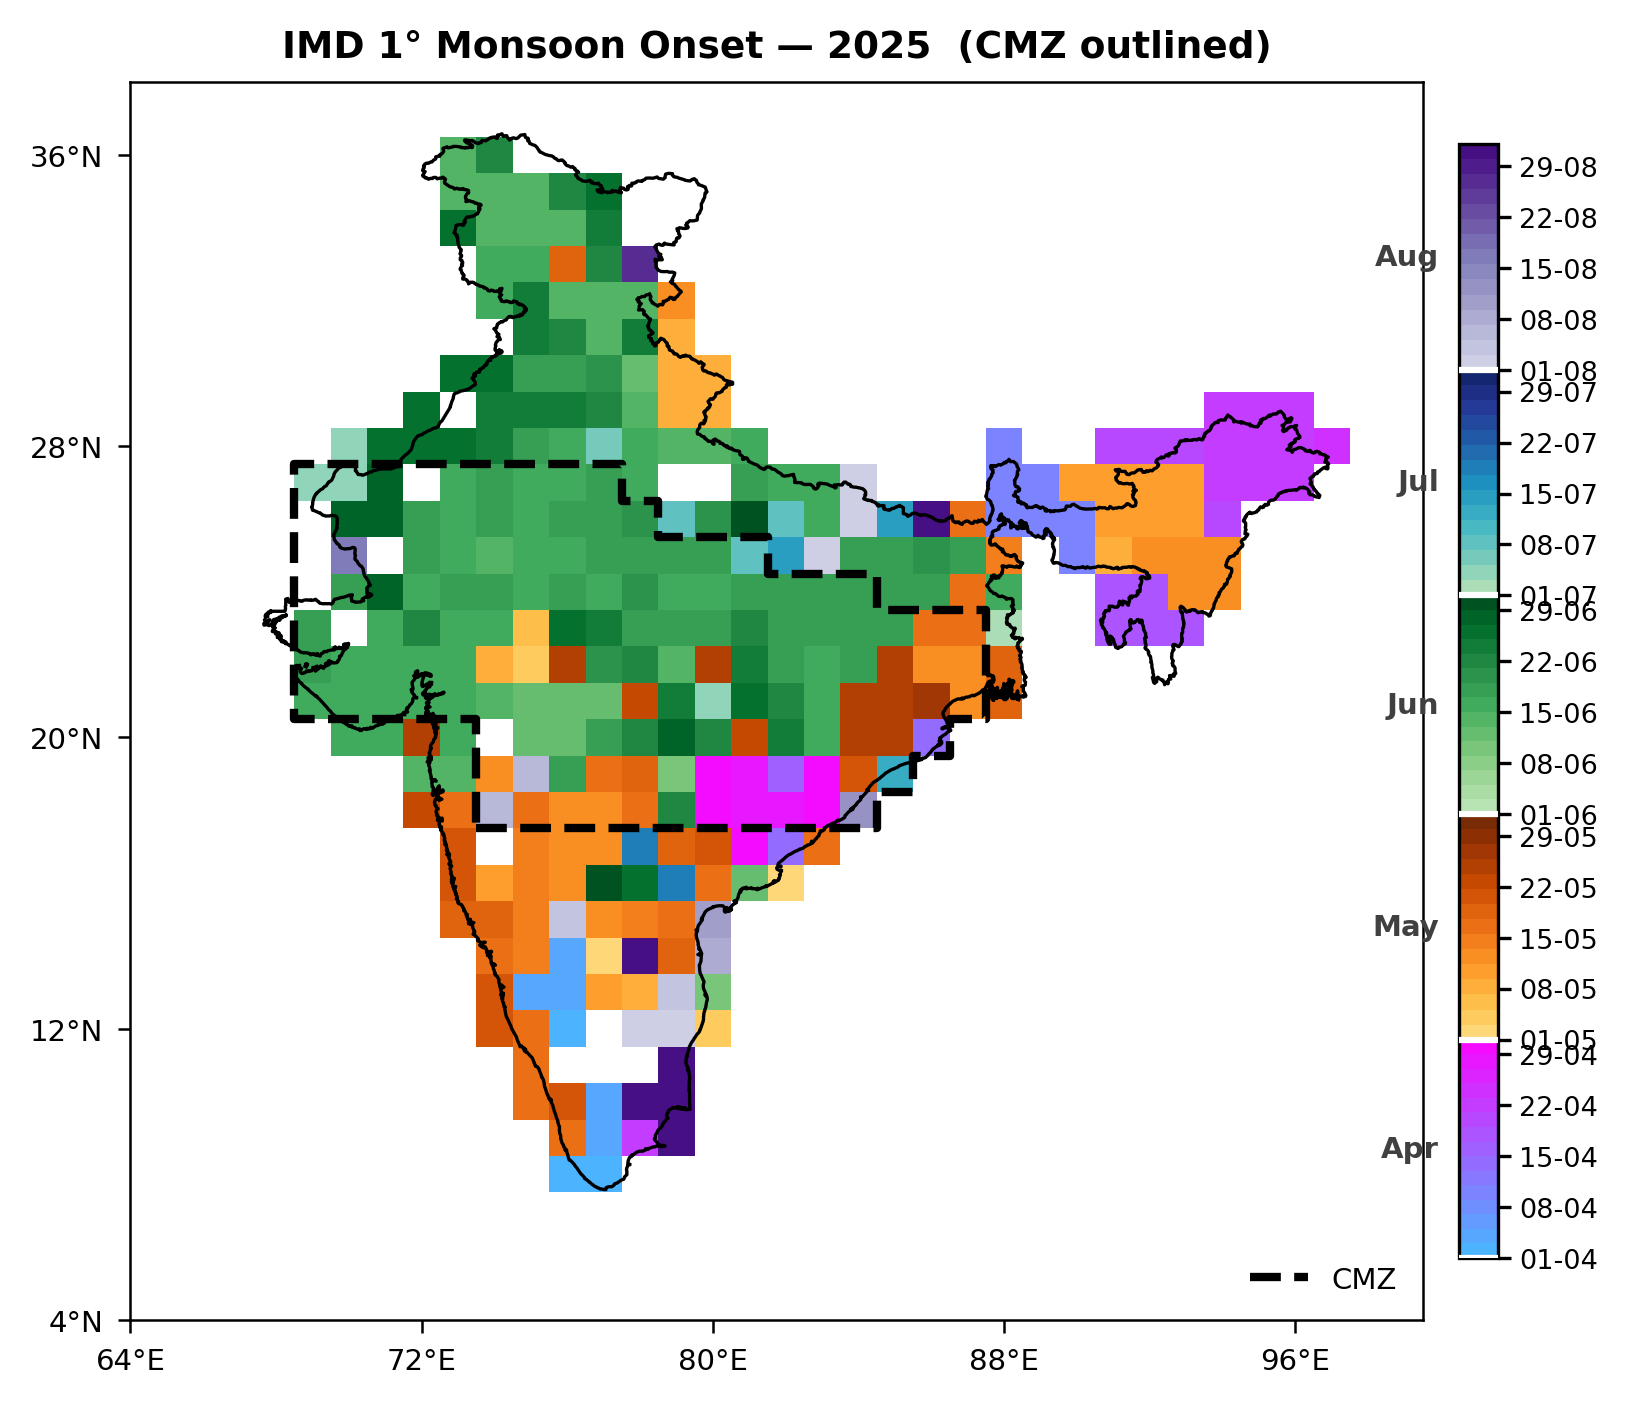

In [69]:
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.path import Path
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.gridspec import GridSpec
from monsoon_onset.plotter import get_india_outline, doy_to_date_string
import os; os.makedirs("../output", exist_ok=True)

# ── CMZ polygon definition ────────────────────────────────────────────────────
cmz_lon = np.array([74, 85, 85, 86, 86, 87, 87, 88, 88, 88, 85, 85, 82, 82, 79, 79, 78, 78, 69, 69, 74, 74])
cmz_lat = np.array([18, 18, 19, 19, 20, 20, 21, 21, 21, 24, 24, 25, 25, 26, 26, 27, 27, 28, 28, 21, 21, 18])
cmz_path = Path(np.column_stack([cmz_lon, cmz_lat]))   # for point-in-polygon tests

# ── Plot onset map with CMZ overlay ──────────────────────────────────────────
fig = plt.figure(figsize=(6, 6), dpi=300)
gs  = GridSpec(1, 14, figure=fig,
               hspace=0.1, wspace=0.3,
               left=0.08, right=0.92, top=0.85, bottom=0.15)
ax  = fig.add_subplot(gs[0, 0:12])

im = ax.pcolormesh(LON_e, LAT_e, masked_data,
                   cmap=cmap_m, norm=norm_m, shading="flat",
                   linewidth=0, edgecolors="none")

# India outline
shp_path = dataset_cfg.get("shapefile")
for lons_b, lats_b in get_india_outline(shapefile_path=shp_path):
    ax.plot(lons_b, lats_b, color="black", linewidth=map_lw)

# CMZ polygon outline
ax.plot(np.append(cmz_lon, cmz_lon[0]),
        np.append(cmz_lat, cmz_lat[0]),
        color="black", linewidth=2, linestyle="--", zorder=10, label="CMZ")
ax.legend(fontsize=SMALL_SIZE, loc="lower right", frameon=False)

ax.patch.set_visible(False)
ax.set_xlim([lon[0] - 2, 100]);  ax.set_ylim([lat[0] - 2, lat[-1]])

yticks = np.arange(lat[0] - 2, lat[-1] + 3, 8)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{int(y)}°N" for y in yticks], fontsize=label_fontsize)
xticks = np.arange(lon[0] - 2, lon[-1] + 3, 8)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{int(x)}°E" for x in xticks], fontsize=label_fontsize)

ax.set_title(f"IMD 1° Monsoon Onset — {YEAR}  (CMZ outlined)", fontsize=MEDIUM_SIZE, fontweight="bold")
ax.grid(False)
ax.tick_params("both", length=tick_length, width=tick_width, which="major")
for side in ["top", "right", "bottom", "left"]:
    ax.spines[side].set_visible(True);  ax.spines[side].set_linewidth(panel_lw)
ax.set_aspect("equal", adjustable="box")

# Colorbar (same as main plot)
pos = ax.get_position()
colorbar_height = pos.height * 0.9
vertical_offset = (pos.height - colorbar_height) / 2
cax = fig.add_axes([pos.x1 + 0.02, pos.y0 + vertical_offset, 0.022, colorbar_height])
cbar = fig.colorbar(im, cax=cax, orientation="vertical", spacing="proportional")
cbar.ax.minorticks_off()

ref = pd.Timestamp(f"{YEAR}-01-01")
tick_doys, tick_labels = [], []
for d0, d1 in month_doys.values():
    doy = d0
    while doy < d1:
        date = ref + pd.Timedelta(days=int(doy) - 1)
        tick_doys.append(doy);  tick_labels.append(date.strftime("%d-%m"))
        doy += 7
cbar.set_ticks(tick_doys)
cbar.set_ticklabels(tick_labels, fontsize=SMALL_SIZE - 0.5)
cbar.ax.tick_params(labelsize=SMALL_SIZE - 0.5, length=3, width=0.8, pad=2)
for month, (d0, d1) in month_doys.items():
    cbar.ax.axhline(d0, color="white", linewidth=1.5, zorder=5)
    cbar.ax.text(-0.5, (d0 + d1) / 2, month,
                 transform=cbar.ax.get_yaxis_transform(),
                 fontsize=SMALL_SIZE, va="center", ha="right", color="0.25", fontweight="bold")

save_path = f"../output/onset_imd_{YEAR}_cmz.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()


## 8. Grid-cell Rainfall Timeseries with Onset & Threshold

Plot the daily rainfall timeseries for a chosen grid point, overlaying:
- the local wet-spell threshold (horizontal dashed line)
- the detected onset date (vertical line)
- a 5-day rolling sum to show how the wet-spell criterion is met

Saved: ../output/timeseries_2025_19.5N_76.5E.png
Onset date : 17-Jun-2025  |  Threshold : 31.8 mm


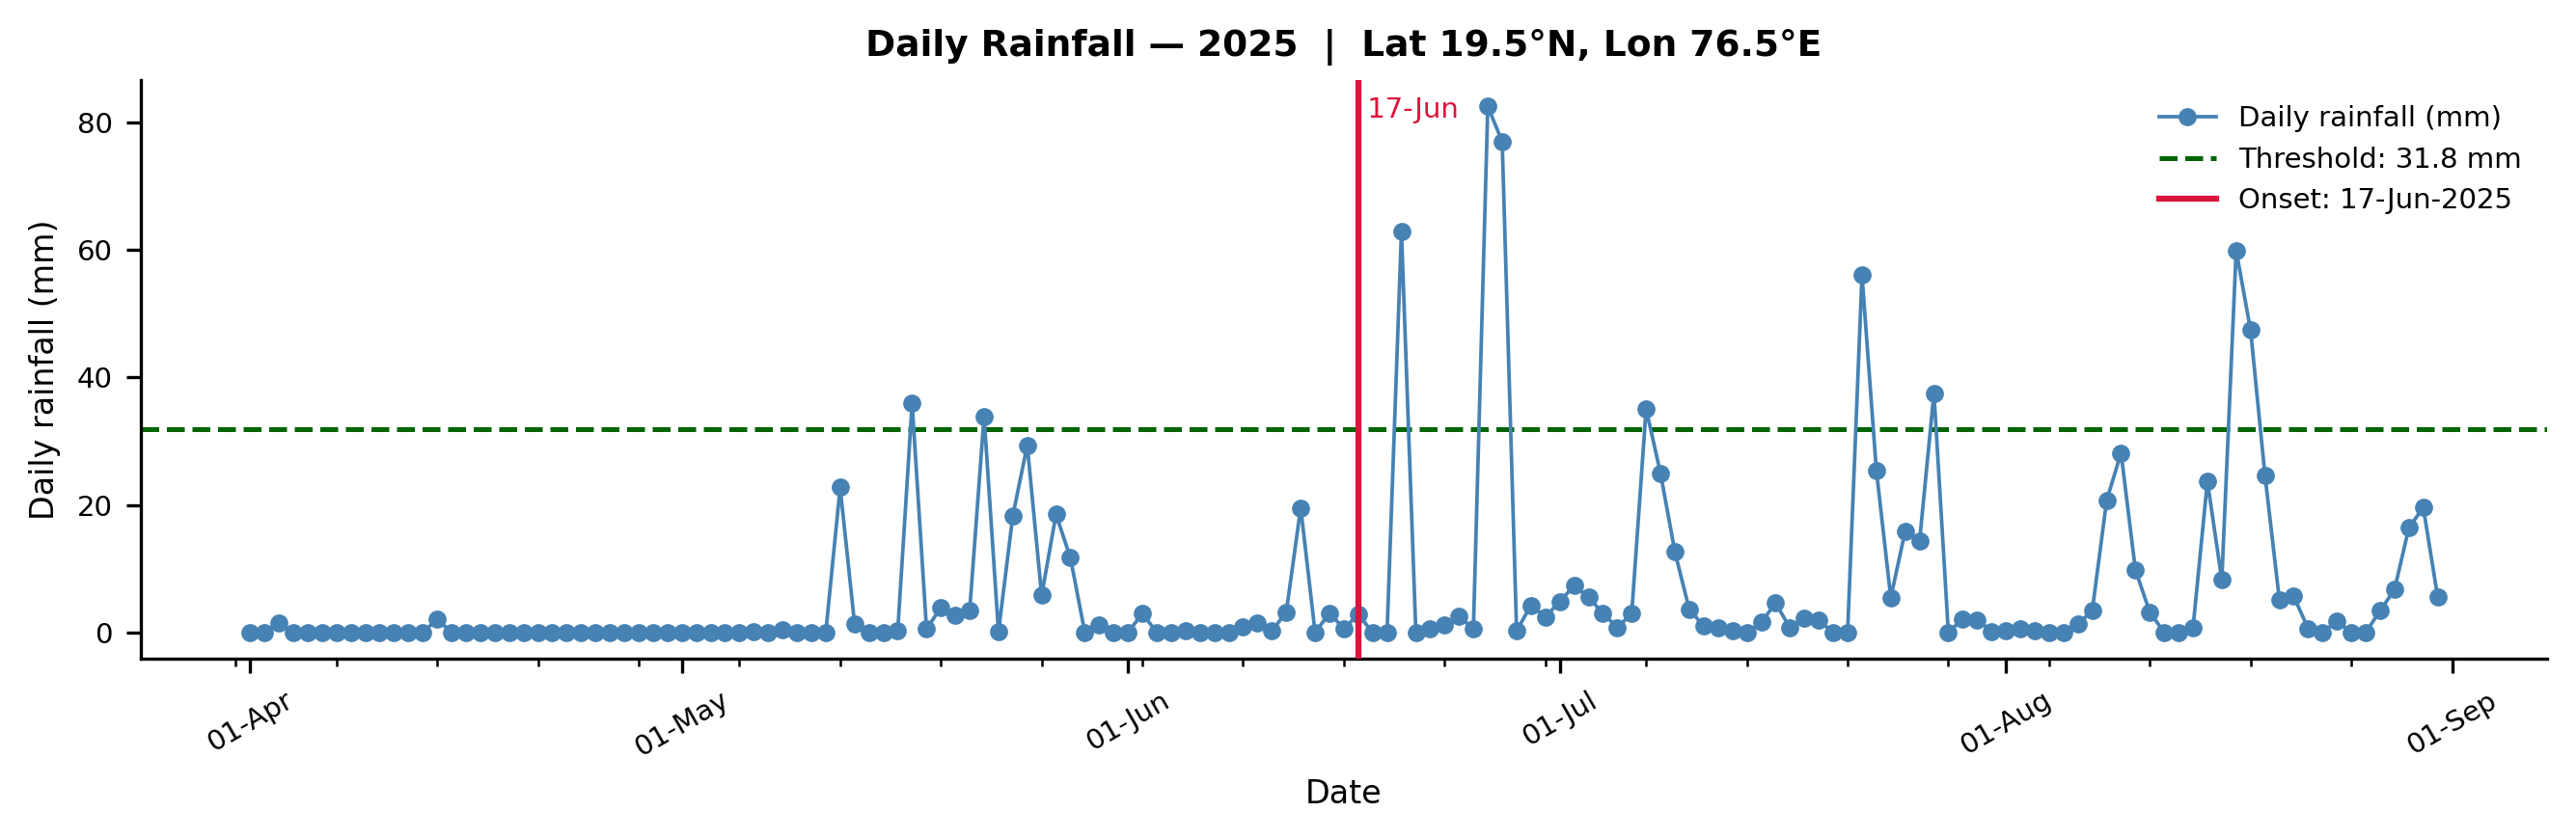

In [ ]:
# ── Choose grid cell (change these to any lat/lon within the domain) ──────────
SEL_LAT = 19.5
SEL_LON = 76.5

# ── Extract timeseries and metadata ──────────────────────────────────────────
rain_cell   = rainfall_da.sel(lat=SEL_LAT, lon=SEL_LON, method="nearest")
thresh_cell = float(thresh_da.sel(lat=SEL_LAT, lon=SEL_LON, method="nearest").squeeze())
onset_cell  = onset_da.sel(lat=SEL_LAT, lon=SEL_LON, method="nearest")

actual_lat = float(rain_cell.lat)
actual_lon = float(rain_cell.lon)

# Onset date as pandas Timestamp (None if no onset)
onset_ts = pd.Timestamp(onset_cell.values) if not np.isnat(onset_cell.values.astype("datetime64[ns]")) else None

# Restrict to April 1 – August 31
t_start   = pd.Timestamp(f"{YEAR}-04-01")
t_end     = pd.Timestamp(f"{YEAR}-08-31")
rain_plot = rain_cell.to_series().loc[t_start:t_end]
times     = rain_plot.index

# ── Single-panel figure ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3), dpi=300)

# Daily rainfall: line + circle markers
ax.plot(times, rain_plot.values,
        color="steelblue", linewidth=0.9, marker="o",
        markersize=4.5, markerfacecolor="steelblue", markeredgewidth=0,
        label="Daily rainfall (mm)", zorder=3)

# Threshold horizontal line
ax.axhline(thresh_cell, color="darkgreen", linewidth=1.2, linestyle="--",
           label=f"Threshold: {thresh_cell:.1f} mm", zorder=2)

# Onset vertical line + label
if onset_ts:
    ax.axvline(onset_ts, color="crimson", linewidth=1.5, linestyle="-",
               zorder=4, label=f"Onset: {onset_ts.strftime('%d-%b-%Y')}")
    ax.text(onset_ts, ax.get_ylim()[1] * 0.97,
            f" {onset_ts.strftime('%d-%b')}",
            color="crimson", fontsize=7, va="top", ha="left")

ax.set_ylabel("Daily rainfall (mm)", fontsize=8)
ax.set_xlabel("Date", fontsize=8)
ax.set_title(f"Daily Rainfall — {YEAR}  |  Lat {actual_lat:.1f}°N, Lon {actual_lon:.1f}°E",
             fontsize=9, fontweight="bold")

ax.legend(fontsize=7, frameon=False, loc="upper right")
ax.tick_params(labelsize=7)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d-%b"))
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
ax.xaxis.set_minor_locator(plt.matplotlib.dates.WeekdayLocator(byweekday=0))
ax.tick_params(axis="x", rotation=30)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
save_path = f"../output/timeseries_{YEAR}_{actual_lat:.1f}N_{actual_lon:.1f}E.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()


In [70]:
# ── Snap / mask onset data to CMZ grid points ────────────────────────────────
# Build a 2-D boolean mask: True where the grid-cell centre is inside CMZ
LON_c, LAT_c = np.meshgrid(onset_da.lon.values, onset_da.lat.values)
pts           = np.column_stack([LON_c.ravel(), LAT_c.ravel()])
cmz_mask_2d   = cmz_path.contains_points(pts).reshape(LON_c.shape)  # [lat, lon]

# Apply mask to the xarray DataArray — NaN outside CMZ
cmz_mask_da = xr.DataArray(cmz_mask_2d, dims=["lat", "lon"],
                            coords={"lat": onset_da.lat, "lon": onset_da.lon})
onset_cmz = onset_da.where(cmz_mask_da)

# DOY version for stats / plotting
onset_doy_cmz = xr.where(
    onset_cmz.notnull(),
    onset_cmz.dt.dayofyear.astype(float),
    np.nan,
)

# Summary stats
valid_cmz = int(onset_doy_cmz.notnull().sum())
total_cmz = int(cmz_mask_2d.sum())
print(f"CMZ grid points with valid onset : {valid_cmz} / {total_cmz}")
print(f"CMZ earliest onset : {doy_to_date_string(float(onset_doy_cmz.min()))}")
print(f"CMZ latest onset   : {doy_to_date_string(float(onset_doy_cmz.max()))}")
mean_doy = float(onset_doy_cmz.mean())
print(f"CMZ mean onset     : {doy_to_date_string(mean_doy)}  (DOY {mean_doy:.1f})")

# The masked DataArray `onset_cmz` and `onset_doy_cmz` are available for further analysis
onset_cmz


CMZ grid points with valid onset : 134 / 141
CMZ earliest onset : 04/12
CMZ latest onset   : 08/15
CMZ mean onset     : 06/09  (DOY 161.4)


<xarray.DataArray 'onset_date' (lat: 33, lon: 35)> Size: 9kB
array([['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ...,
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT']],
      shape=(33, 35), dtype='datetime64[ns]')
Coordinates:
  * lat      (lat) float64 264B 6.5 7.5 8.5 9.5 10.5 ... 35.5 36.5 37.5 38.5
  * lon      (lon) float64 280B 66.5 67.5 68.5 69.5 ... 97.5 98.5 99.5 100.5
Attributes:
    description:           Onset date with dry-spell veto
    start_date:            2025-04-01
    wet_spell_window:      5
    dry_spell_window:      10
    dry_spell_threshold:   5
    dry_spell_check_days:  30
    mok_filter:            False

## First Wet Spell Date (No Dry-Spell Check)

Compute the **first wet spell date** for 2025 — identical wet-spell criteria as the main onset detection, but *without* the dry-spell veto. This lets us see how much the dry-spell veto delays the detected onset date.

In [76]:
import importlib
import monsoon_onset.detector as _det
importlib.reload(_det)
from monsoon_onset.detector import detect_first_wet_spell

first_wet_da = detect_first_wet_spell(rainfall_da, thresh_da, YEAR, onset_cfg)
first_wet_da


First wet spell detection start: 2025-04-01
  Valid first wet spells: 342/1155 (29.6%)


<xarray.DataArray 'first_wet_spell_date' (lat: 33, lon: 35)> Size: 9kB
array([['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ...,
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT']],
      shape=(33, 35), dtype='datetime64[ns]')
Coordinates:
  * lat      (lat) float64 264B 6.5 7.5 8.5 9.5 10.5 ... 35.5 36.5 37.5 38.5
  * lon      (lon) float64 280B 66.5 67.5 68.5 69.5 ... 97.5 98.5 99.5 100.5
Attributes:
    description:       First wet spell date (no dry-spell veto)
    start_date:        2025-04-01
    wet_spell_window:  5

In [ ]:
import numpy as np
import pandas as pd

# Compute the delay (onset - first_wet_spell) in days
onset_doy_vals   = np.where(pd.notna(onset_da.values),
                             (onset_da.values.astype("datetime64[D]") -
                              np.datetime64(f"{YEAR}-01-01", "D")).astype(float) + 1,
                             np.nan)
first_wet_doy_vals = np.where(pd.notna(first_wet_da.values),
                               (first_wet_da.values.astype("datetime64[D]") -
                                np.datetime64(f"{YEAR}-01-01", "D")).astype(float) + 1,
                               np.nan)

delay_vals = onset_doy_vals - first_wet_doy_vals   # positive → onset delayed

delay_da = xr.DataArray(
    delay_vals,
    coords=[("lat", onset_da.lat.values), ("lon", onset_da.lon.values)],
    name="onset_delay_days",
    attrs={"description": "Onset date minus first wet spell date (days); positive = delayed by veto"},
)


Grid points with valid delay: 326
  Mean delay  : 15.7 days
  Median delay: 0.0 days
  Max delay   : 218 days
  % points with delay > 0: 36.5%
  % points with delay = 0: 63.5%


### Spatial Comparison: First Wet Spell vs Onset Date

Side-by-side maps of the first wet spell date and the detected onset date, plus a difference (delay) map showing how much the dry-spell veto pushes the onset later.

Loaded India outline from: /Users/Rajat/Library/CloudStorage/OneDrive-TheUniversityofChicago/documents/conferences/icts_monsoon_26/mr_onset/data/ind_map_shpfile/india_shapefile.shp
Loaded India outline from: /Users/Rajat/Library/CloudStorage/OneDrive-TheUniversityofChicago/documents/conferences/icts_monsoon_26/mr_onset/data/ind_map_shpfile/india_shapefile.shp
Loaded India outline from: /Users/Rajat/Library/CloudStorage/OneDrive-TheUniversityofChicago/documents/conferences/icts_monsoon_26/mr_onset/data/ind_map_shpfile/india_shapefile.shp


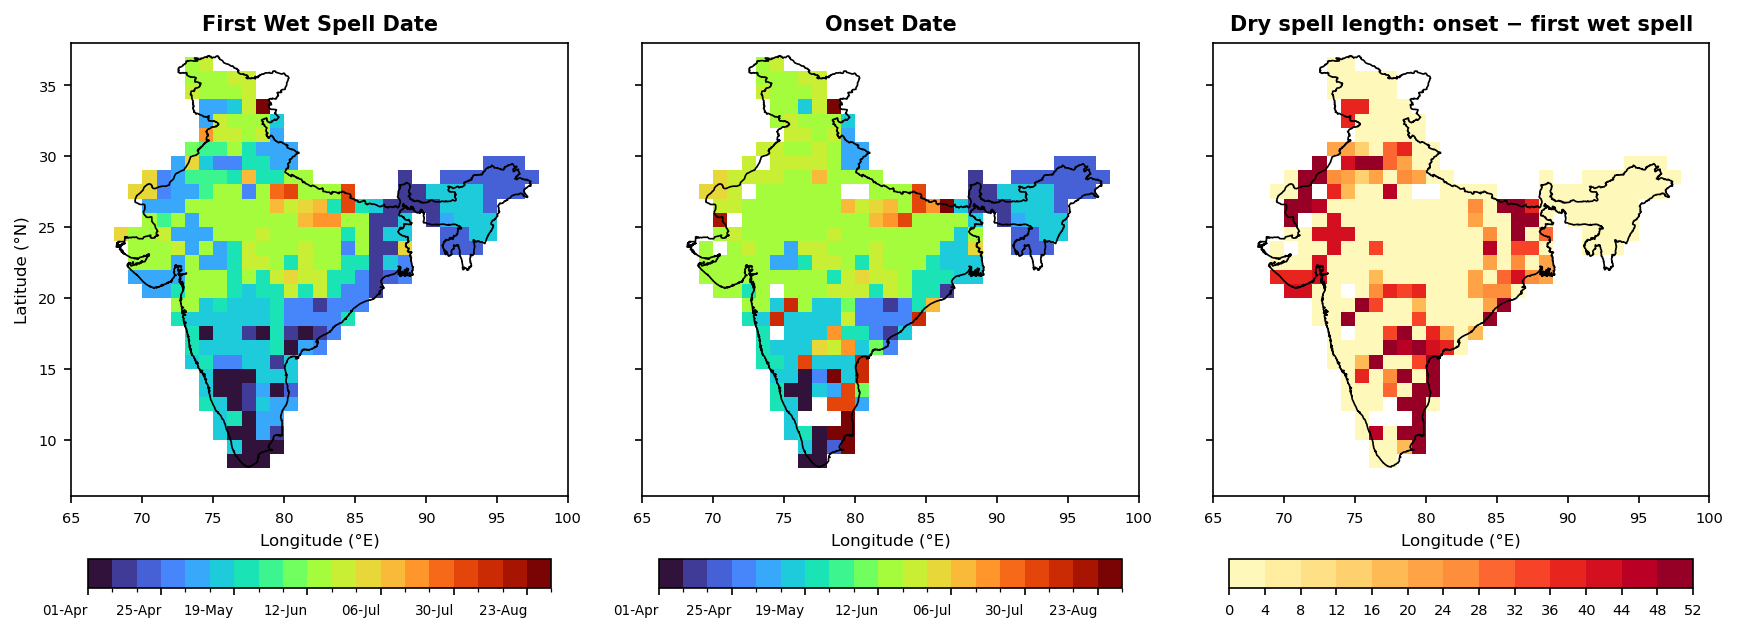

In [109]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as mgridspec
import numpy as np
import pandas as pd
from monsoon_onset.plotter import get_india_outline

# ── correct shapefile path (same as all other plots in this notebook) ─────────
shp_path = dataset_cfg.get("shapefile")

# ---- shared monthly colormap (April DOY 91 … August DOY 243) ---------------
doy_bounds = list(range(91, 244, 8))
if doy_bounds[-1] < 243:
    doy_bounds.append(243)
N_bins = len(doy_bounds) - 1
cmap_seq    = plt.cm.turbo
cmap_shared = mcolors.ListedColormap(
    [cmap_seq(i / (N_bins - 1)) for i in range(N_bins)])
norm_shared = mcolors.BoundaryNorm(doy_bounds, N_bins)

def doy_arr(da):
    ref = np.datetime64(f"{YEAR}-01-01", "D")
    return np.where(pd.notna(da.values),
                    (da.values.astype("datetime64[D]") - ref).astype(float) + 1,
                    np.nan)

fws_doy = doy_arr(first_wet_da)
ons_doy = doy_arr(onset_da)

# ---- discrete colormap for the delay panel ----------------------------------
valid_delays = delay_da.values[np.isfinite(delay_da.values)]
max_delay    = 50#max(1, int(np.nanpercentile(valid_delays, 95)) + 1)
step         = 4
max_bin      = int(np.ceil(max_delay / step)) * step
delay_bounds = list(range(0, max_bin + step, step))
N_delay      = len(delay_bounds) - 1
cmap_delay   = mcolors.ListedColormap(
    plt.cm.YlOrRd(np.linspace(0.05, 0.95, N_delay)))
norm_delay   = mcolors.BoundaryNorm(delay_bounds, N_delay)

# ---- figure -----------------------------------------------------------------
fig = plt.figure(figsize=(12, 6), dpi=150)
gs  = mgridspec.GridSpec(1, 3, figure=fig, wspace=0.15,
                          left=0.06, right=0.97, top=0.88, bottom=0.18)

map_extent   = [65, 100, 6, 38]
panel_titles = ["First Wet Spell Date",
                "Onset Date",
                "Dry spell length: onset − first wet spell"]

# ── panels 0 & 1: date maps ──────────────────────────────────────────────────
for pi, (doy_data, da_obj) in enumerate([(fws_doy, first_wet_da), (ons_doy, onset_da)]):
    ax = fig.add_subplot(gs[pi])
    ax.set_aspect("equal", adjustable="box")

    im = ax.pcolormesh(da_obj.lon.values, da_obj.lat.values, doy_data,
                       cmap=cmap_shared, norm=norm_shared,
                       shading="nearest", rasterized=True)

    for lons_b, lats_b in get_india_outline(shapefile_path=shp_path):
        ax.plot(lons_b, lats_b, color="black", linewidth=0.8)

    ax.patch.set_visible(False)          # white outside data — same as onset map
    ax.set_xlim(map_extent[0], map_extent[1])
    ax.set_ylim(map_extent[2], map_extent[3])
    ax.set_title(panel_titles[pi], fontsize=10, fontweight="bold")
    ax.set_xlabel("Longitude (°E)", fontsize=8)
    ax.tick_params(labelsize=7)
    if pi == 0:
        ax.set_ylabel("Latitude (°N)", fontsize=8)
    else:
        ax.set_yticklabels([])

    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.1,
                        fraction=0.046, aspect=16,
                        boundaries=doy_bounds, ticks=doy_bounds[::3])
    tick_dates = [pd.Timestamp(f"{YEAR}-01-01") + pd.Timedelta(days=int(d) - 1)
                  for d in doy_bounds[::3]]
    cbar.ax.set_xticklabels(
        [t.strftime("%d-%b") for t in tick_dates],
        rotation=0, fontsize=6.5, ha="right")

# ── panel 2: discrete delay map ──────────────────────────────────────────────
ax2 = fig.add_subplot(gs[2])
ax2.set_aspect("equal", adjustable="box")

im2 = ax2.pcolormesh(delay_da.lon.values, delay_da.lat.values,
                      delay_da.values,
                      cmap=cmap_delay, norm=norm_delay,
                      shading="nearest", rasterized=True)

for lons_b, lats_b in get_india_outline(shapefile_path=shp_path):
    ax2.plot(lons_b, lats_b, color="black", linewidth=0.8)

ax2.patch.set_visible(False)             # white outside data — same as onset map
ax2.set_xlim(map_extent[0], map_extent[1])
ax2.set_ylim(map_extent[2], map_extent[3])
ax2.set_title(panel_titles[2], fontsize=10, fontweight="bold")
ax2.set_xlabel("Longitude (°E)", fontsize=8)
ax2.set_yticklabels([])
ax2.tick_params(labelsize=7)

cbar2 = fig.colorbar(im2, ax=ax2, orientation="horizontal", pad=0.1,
                      fraction=0.046, aspect=16,
                      boundaries=delay_bounds, ticks=delay_bounds,
                      spacing="uniform")
cbar2.ax.set_xticklabels([str(b) for b in delay_bounds], fontsize=7)
cbar2.ax.tick_params(labelsize=7)

plt.savefig(f"../output/comparison_fws_vs_onset_{YEAR}.png", dpi=150, bbox_inches="tight")
plt.show()
